In [12]:
#   1. 抽样长度改为 1440
#   2. 所有列使用相同起点（对齐采样）
#   3. silhouette 使用 SBD 距离矩阵计算

import os
import random
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score
from tslearn.clustering import KShape

# ---------- 配置 ----------
INPUT_CSV = "../../data/electricityLondon.csv"       # 修改为你的路径
SAMPLED_CSV = "kshape_results_1440_0Start/sampled_1440_0Start.csv"    # 输出的采样文件
RANDOM_SEED = 42
SAMPLE_LENGTH = 1440                # 抽样长度=1440
KS = [3, 4, 5, 6, 7, 8, 9]                # 聚类数量集合
OUTPUT_FOLDER = "kshape_results_1440_0Start"
# -----------------------------

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# 本文件任务：

1、数据抽样提取：抽取前1440个数据

2、试探聚类，选取最好的聚类数

3、实现聚类，并且给出各簇波形图 & 聚类簇中心对比图

4、分析各簇成分

## 数据提取

窗口对齐抽取1440个数据，相当于60天

缺失值处理采用周期对其插值法，周期为24h，

$$
x_t = \frac{x_{t-24} + x_{t+24}}{2}
$$

In [8]:
# ----------------------------------------------------
# 1. 读取 combined.csv（第一列是时间索引）
# ----------------------------------------------------
print("读取 CSV:", INPUT_CSV)
df = pd.read_csv(INPUT_CSV, header=0)

first_col = df.columns[0]
try:
    df[first_col] = pd.to_datetime(df[first_col])
    df = df.set_index(first_col)
    print(f"第一列 `{first_col}` 已设为 DatetimeIndex。")
except:
    df = df.set_index(first_col)
    print(f"无法解析为 datetime，但已将 `{first_col}` 设为索引。")

n_rows = df.shape[0]
if n_rows < SAMPLE_LENGTH:
    raise ValueError(f"数据长度 {n_rows} 小于 {SAMPLE_LENGTH}，无法抽取。")

print(f"总时间步数 = {n_rows}，将抽取对齐的 1440 个时间步。")

# ----------------------------------------------------
# 2. 统一随机起点抽样（所有列对齐一致）
# ----------------------------------------------------
#start = random.randint(0, n_rows - SAMPLE_LENGTH)
start = 0 #跑本年前60天
end = start + SAMPLE_LENGTH
print(f"抽样窗口起点 = {start}，终点 = {end}")

sampled_df = df.iloc[start:end]
sampled_df.to_csv(SAMPLED_CSV, index=False)
print(f"采样数据保存为: {SAMPLED_CSV}")

# ----------------------------------------------------
# 3. 读入采样后 csv，并做周期对齐缺失值填补
# ----------------------------------------------------
data_df = pd.read_csv(SAMPLED_CSV, header=0)

PERIOD = 24
missing = data_df.isna().sum().sum()

if missing > 0:
    print(f"发现 {missing} 个缺失值，使用周期对齐插值 (period={PERIOD}) 填补。")

    for col_idx, col_name in enumerate(data_df.columns):
        series = data_df[col_name].values
        nan_idx = np.where(np.isnan(series))[0]

        if len(nan_idx) == 0:
            continue

        print(f"列 `{col_name}` (第 {col_idx + 1} 列) 缺失位置: {nan_idx.tolist()}")

        # -------- 单点缺失 --------
        if len(nan_idx) == 1:
            t = nan_idx[0]
            series[t] = 0.5 * (series[t - PERIOD] + series[t + PERIOD])

        # -------- 两个连续缺失 --------
        elif len(nan_idx) == 2 and nan_idx[1] == nan_idx[0] + 1:
            t0, t1 = nan_idx
            series[t0] = 0.5 * (series[t0 - PERIOD] + series[t0 + PERIOD])
            series[t1] = 0.5 * (series[t1 - PERIOD] + series[t1 + PERIOD])

        else:
            raise ValueError(
                f"列 {col_name} 出现不符合假设的缺失模式: {nan_idx}"
            )

        data_df[col_name] = series

# ----------------------------------------------------
# 4. 构建 (n_series, series_len) 的矩阵
# ----------------------------------------------------
X = data_df.values.T.astype(float)
X = data_df.values.T.astype(float)
n_series, series_length = X.shape
print(f"共有 {n_series} 个地点，每个序列长度 {series_length}")

读取 CSV: ../../data/electricityLondon.csv
第一列 `timestamp` 已设为 DatetimeIndex。
总时间步数 = 17544，将抽取对齐的 1440 个时间步。
抽样窗口起点 = 0，终点 = 1440
采样数据保存为: kshape_results_1440_0Start/sampled_1440_0Start.csv
发现 3 个缺失值，使用周期对齐插值 (period=24) 填补。
列 `Robin_office_Soledad` (第 42 列) 缺失位置: [825]
列 `Mouse_health_Modesto` (第 63 列) 缺失位置: [845, 846]
共有 68 个地点，每个序列长度 1440


### 数据预处理 

标准化

In [9]:
# ----------------------------------------------------
# 5. 对每个序列做 Z-normalization
# ----------------------------------------------------
X_norm = np.empty_like(X)
for i in range(n_series):
    s = X[i]
    mu = s.mean()
    sigma = s.std()
    if sigma == 0 or np.isnan(sigma):
        X_norm[i] = s - mu
    else:
        X_norm[i] = (s - mu) / sigma


### 定义SBD距离

### 定义SBD距离

In [10]:
# ----------------------------------------------------
# 6. SBD 距离矩阵计算 silhouette
# ----------------------------------------------------

from numpy.linalg import norm
from scipy.signal import fftconvolve

def sbd(x, y):
    """
    Shape-Based Distance（SBD）计算，等价于 tslearn KShape 内部实现。
    输入必须是 1D numpy 数组。
    """
    x = np.array(x)
    y = np.array(y)
    # Normalize
    x = (x - x.mean()) / (x.std() + 1e-8)
    y = (y - y.mean()) / (y.std() + 1e-8)

    # NCC via FFT-based convolution
    ncc = fftconvolve(x, y[::-1], mode='full')
    denom = norm(x) * norm(y) + 1e-8
    ncc /= denom

    # Maximum NCC
    max_ncc = np.max(ncc)

    # SBD distance
    return 1 - max_ncc


# --- 用 SBD 自定义 silhouette 评分 ---
def silhouette_score_sbd(X, labels):
    """
    使用 SBD（Shape Based Distance）构造 silhouette 分数
    X: (n_series, length)
    labels: 聚类标签
    """

    n = len(X)

    # --- 预计算 SBD 距离矩阵 ---
    D = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(i+1, n):
            dist = sbd(X[i], X[j])
            D[i, j] = dist
            D[j, i] = dist

    # --- 手工计算 silhouette ---
    sil_values = np.zeros(n)

    for i in range(n):
        same_cluster = labels == labels[i]
        other_clusters = labels != labels[i]

        # a(i): 同簇平均距离
        a = D[i, same_cluster].mean() if same_cluster.sum() > 1 else 0

        # b(i): 其他簇中最小平均距离
        b = np.inf
        for cid in set(labels):
            if cid == labels[i]:
                continue
            idx = labels == cid
            b = min(b, D[i, idx].mean())

        sil_values[i] = (b - a) / max(a, b)

    return sil_values.mean()

## 试探聚类

In [13]:
# ----------------------------------------------------
# 7. 对每个 k 做 KShape 聚类并计算 silhouette
# ----------------------------------------------------
results = {}
best_k = None
best_score = -1

for k in KS:
    print("\n" + "-" * 50)
    print(f"聚类 k = {k}")

    if n_series < k:
        print(f"序列数量 {n_series} < k {k}，跳过。")
        continue

    try:
        model = KShape(n_clusters=k, n_init=10, random_state=RANDOM_SEED)
        labels = model.fit_predict(X_norm)
    except Exception as e:
        print("KShape 错误：", e)
        continue

    # —— 使用 SBD 距离矩阵计算 silhouette ——
    score = silhouette_score_sbd(X_norm, labels)

    # 聚类信息
    clusters_info = {}
    cols = data_df.columns
    for cid in range(k):
        idxs = np.where(labels == cid)[0]
        members = cols[idxs].tolist()
        clusters_info[cid] = {
            "size": len(idxs),
            "members": members
        }

    results[k] = {
        "silhouette": float(score),
        "clusters": clusters_info,
        "labels": labels
    }

    # 保存 cluster assignment
    out_df = pd.DataFrame({
        "location": cols,
        "label": labels
    })
    out_path = os.path.join(OUTPUT_FOLDER, f"clusters_k{k}.csv")
    out_df.to_csv(out_path, index=False)
    print(f"保存聚类文件：{out_path}")
    print(f"k={k} 的 silhouette(SBD) = {score:.6f}")

    if score > best_score:
        best_score = score
        best_k = k


--------------------------------------------------
聚类 k = 3
保存聚类文件：kshape_results_1440_0Start\clusters_k3.csv
k=3 的 silhouette(SBD) = 0.497464

--------------------------------------------------
聚类 k = 4
保存聚类文件：kshape_results_1440_0Start\clusters_k4.csv
k=4 的 silhouette(SBD) = 0.508619

--------------------------------------------------
聚类 k = 5
保存聚类文件：kshape_results_1440_0Start\clusters_k5.csv
k=5 的 silhouette(SBD) = 0.546301

--------------------------------------------------
聚类 k = 6
保存聚类文件：kshape_results_1440_0Start\clusters_k6.csv
k=6 的 silhouette(SBD) = 0.384754

--------------------------------------------------
聚类 k = 7
保存聚类文件：kshape_results_1440_0Start\clusters_k7.csv
k=7 的 silhouette(SBD) = 0.300772

--------------------------------------------------
聚类 k = 8
保存聚类文件：kshape_results_1440_0Start\clusters_k8.csv
k=8 的 silhouette(SBD) = 0.327472

--------------------------------------------------
聚类 k = 9
保存聚类文件：kshape_results_1440_0Start\clusters_k9.csv
k=9 的 silhouette(SBD) = 0

### 得到试探结果

In [14]:
# ----------------------------------------------------
# 8. 输出最终最佳聚类信息
# ----------------------------------------------------
print("\n" + "=" * 60)
print(f"最佳 k = {best_k}，对应 silhouette(SBD) = {best_score:.6f}")

for k, info in results.items():
    print("\n" + "-" * 40)
    print(f"K = {k}, silhouette = {info['silhouette']:.6f}")
    for cid, cinfo in info["clusters"].items():
        print(f"  簇 {cid}: 大小 = {cinfo['size']}")
        print(f"    成员 = {cinfo['members']}")


最佳 k = 5，对应 silhouette(SBD) = 0.546301

----------------------------------------
K = 3, silhouette = 0.497464
  簇 0: 大小 = 55
    成员 = ['Robin_public_Carolina', 'Robin_education_Zenia', 'Robin_office_Dina', 'Robin_education_Derick', 'Robin_education_Leslie', 'Robin_office_Sammie', 'Robin_education_Mercedes', 'Robin_education_Julius', 'Robin_education_Lashandra', 'Robin_education_Lizbeth', 'Robin_office_Gayle', 'Robin_office_Shirlene', 'Robin_education_Madeline', 'Robin_education_Jasper', 'Robin_office_Wai', 'Robin_education_Terrance', 'Robin_office_Addie', 'Robin_education_Cecilia', 'Robin_education_Kiera', 'Robin_education_So', 'Robin_office_Maryann', 'Robin_office_Serena', 'Robin_education_Derrick', 'Robin_education_Megan', 'Robin_office_Adolph', 'Robin_office_Lindsay', 'Robin_education_Takako', 'Robin_office_Victor', 'Robin_education_Margarito', 'Robin_public_Cami', 'Robin_education_Kristopher', 'Robin_education_Billi', 'Robin_office_Donald', 'Robin_assembly_Colleen', 'Robin_office_

## 对于5类，完成聚类，绘图

In [15]:
N_CLUSTERS = 5

In [16]:
# ------------------ KShape 聚类 ------------------
print("运行 KShape 聚类 (k=5)...")
model = KShape(n_clusters=N_CLUSTERS, n_init=10, random_state=RANDOM_SEED)
labels = model.fit_predict(X_norm)
print("聚类完成。")

# 计算并打印 SBD-silhouette（基于归一化序列）
print("计算 SBD-based silhouette...")
sil_score = silhouette_score_sbd(X_norm, labels)
print(f"SBD silhouette (k={N_CLUSTERS}) = {sil_score:.6f}")

# ------------------ 为每个簇找到代表序列（真实序列中与 cluster center 最接近的那个） ------------------
# model.cluster_centers_ 是 KShape 的原型（长度 = series_length），但一般是归一化的向量
centers = model.cluster_centers_  # shape (k, length) ; dtype float

cluster_info = {}
cols = data_df.columns.tolist()

for cid in range(N_CLUSTERS):
    member_idx = np.where(labels == cid)[0]
    members = [cols[i] for i in member_idx]
    # 如果没有成员（极少见），跳过
    if len(member_idx) == 0:
        print(f"簇 {cid} 无成员，跳过.")
        cluster_info[cid] = {"size": 0, "members": [], "rep_index": None}
        continue

    # 找到 member 中与 centers[cid] 在 SBD 上距离最小的真实序列（用归一化的 member 与 center 比较）
    best_i = None
    best_d = np.inf
    for i in member_idx:
        d = sbd(X_norm[i], centers[cid].ravel())
        if d < best_d:
            best_d = d
            best_i = i

    cluster_info[cid] = {
        "size": int(len(member_idx)),
        "members": members,
        "rep_index": int(best_i),
        "rep_name": cols[best_i],
        "rep_distance_to_center": float(best_d)
    }

运行 KShape 聚类 (k=5)...
聚类完成。
计算 SBD-based silhouette...
SBD silhouette (k=5) = 0.546301


In [17]:
# 保存聚类结果到 CSV
assign_df = pd.DataFrame({
    "location": cols,
    "label": labels
})
assign_csv = os.path.join(OUTPUT_FOLDER, f"clusters_k{N_CLUSTERS}.csv")
assign_df.to_csv(assign_csv, index=False)
print(f"聚类分配已保存：{assign_csv}")

# 保存每簇信息（members + representative）
import json
cluster_info_path = os.path.join(OUTPUT_FOLDER, f"clusters_info_k{N_CLUSTERS}.json")
with open(cluster_info_path, "w", encoding="utf-8") as f:
    json.dump(cluster_info, f, indent=2, ensure_ascii=False)
print(f"每簇信息（包含代表序列）已保存：{cluster_info_path}")

# 也保存代表序列（原始振幅）到 CSV
reps = []
for cid in range(N_CLUSTERS):
    info = cluster_info[cid]
    if info.get("rep_index") is None:
        continue
    idx = info["rep_index"]
    row = {
        "cluster": cid,
        "rep_name": info["rep_name"],
        "rep_index": idx,
        "distance_to_center": info["rep_distance_to_center"]
    }
    reps.append(row)
reps_df = pd.DataFrame(reps)
reps_df.to_csv(os.path.join(OUTPUT_FOLDER, f"cluster_representatives_k{N_CLUSTERS}.csv"), index=False)

聚类分配已保存：kshape_results_1440_0Start\clusters_k5.csv
每簇信息（包含代表序列）已保存：kshape_results_1440_0Start\clusters_info_k5.json


In [18]:
import matplotlib.pyplot as plt

# ------------------ 绘图（每簇一张图） ------------------
# Matplotlib 字体设置为 Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

for cid in range(N_CLUSTERS):
    info = cluster_info[cid]
    member_idx = np.where(labels == cid)[0]
    if len(member_idx) == 0:
        continue

    fig, ax = plt.subplots(figsize=(12, 4))
    # 绘制所有成员（原始振幅）
    for i in member_idx:
        ax.plot(np.arange(series_length), X[i], linewidth=0.6, alpha=0.7, zorder=1, solid_capstyle='round', color='0.6')
    # 绘制代表序列（原始振幅）
    rep_idx = info.get("rep_index")
    if rep_idx is not None:
        ax.plot(np.arange(series_length), X[rep_idx], linewidth=1.2, alpha=1.0, color='red', zorder=2, label=f"Cluster {cid} center ({info['rep_name']})")

    # 轴和格式
    ax.set_xlabel("Time step", fontsize=12)
    ax.set_ylabel("Amplitude (original, before preprocessing)", fontsize=12)
    ax.set_title(f"Cluster {cid} — {info['size']} series", fontsize=14)
    # x ticks 每 500 步
    tick_step = 500
    ticks = list(range(0, series_length, tick_step))
    # 确保最后一个点也被标注
    if (series_length - 1) not in ticks:
        ticks.append(series_length - 1)
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(t) for t in ticks], fontsize=10)
    # 去掉网格
    ax.grid(False)
    # 轻微收紧边距
    plt.tight_layout()

    # 保存图像（PNG）
    out_png = os.path.join(OUTPUT_FOLDER, f"cluster_{cid}_members_with_center.png")
    fig.savefig(out_png, dpi=300)
    plt.close(fig)
    print(f"簇 {cid} 图像已保存：{out_png}")

print("全部完成。输出目录：", OUTPUT_FOLDER)

簇 0 图像已保存：kshape_results_1440_0Start\cluster_0_members_with_center.png
簇 1 图像已保存：kshape_results_1440_0Start\cluster_1_members_with_center.png
簇 2 图像已保存：kshape_results_1440_0Start\cluster_2_members_with_center.png
簇 3 图像已保存：kshape_results_1440_0Start\cluster_3_members_with_center.png
簇 4 图像已保存：kshape_results_1440_0Start\cluster_4_members_with_center.png
全部完成。输出目录： kshape_results_1440_0Start


In [21]:
# ------------------ 绘制三个聚类中心的对比图 ------------------
plt.rcParams['font.family'] = 'Times New Roman'

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['green', 'blue', 'black', 'red', 'yellow']  # Cluster 0: green, Cluster 1: blue

for cid in range(5):  # 假设只有两个簇
    info = cluster_info[cid]
    rep_idx = info.get("rep_index")
    if rep_idx is None:
        print(f"警告：Cluster {cid} 没有代表序列，跳过。")
        continue
    ax.plot(
        np.arange(series_length),
        X[rep_idx],
        linewidth=1.8,  # 稍粗一点以突出中心线
        alpha=1.0,
        color=colors[cid],
        zorder=2,
        label=f"Cluster {cid} center ({info['rep_name']})"
    )

# 轴和格式（完全复用原风格）
ax.set_xlabel("Time step", fontsize=12)
ax.set_ylabel("Amplitude (original, before preprocessing)", fontsize=12)
ax.set_title("Cluster Centers Comparison", fontsize=14)

# x ticks 每 500 步
tick_step = 500
ticks = list(range(0, series_length, tick_step))
if (series_length - 1) not in ticks:
    ticks.append(series_length - 1)
ax.set_xticks(ticks)
ax.set_xticklabels([str(t) for t in ticks], fontsize=10)

# 关闭网格（确保无网格线）
ax.grid(False)

# 图例
ax.legend(fontsize=11, loc='upper right')

# 紧凑布局
plt.tight_layout()

# 保存图像
out_png = os.path.join(OUTPUT_FOLDER, "cluster_centers_comparison.png")
fig.savefig(out_png, dpi=300, bbox_inches='tight')
plt.close(fig)

print(f"聚类中心对比图已保存：{out_png}")

聚类中心对比图已保存：kshape_results_1440_0Start\cluster_centers_comparison.png


## 分析每个cluster成分

In [32]:
mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["font.size"] = 12

title_fontsize = 29
legend_fontsize = 25
legend_title_fontsize = 28


========== Label Statistics ==========

Cluster 0
  Total samples: 2
  Second word counts:
    education: 1
    office: 1
----------------------------------------
Cluster 1
  Total samples: 2
  Second word counts:
    education: 1
    office: 1
----------------------------------------
Cluster 2
  Total samples: 10
  Second word counts:
    lodging: 10
----------------------------------------
Cluster 3
  Total samples: 3
  Second word counts:
    education: 1
    health: 1
    science: 1
----------------------------------------
Cluster 4
  Total samples: 51
  Second word counts:
    public: 2
    education: 19
    office: 24
    assembly: 1
    health: 4
    lodging: 1
----------------------------------------


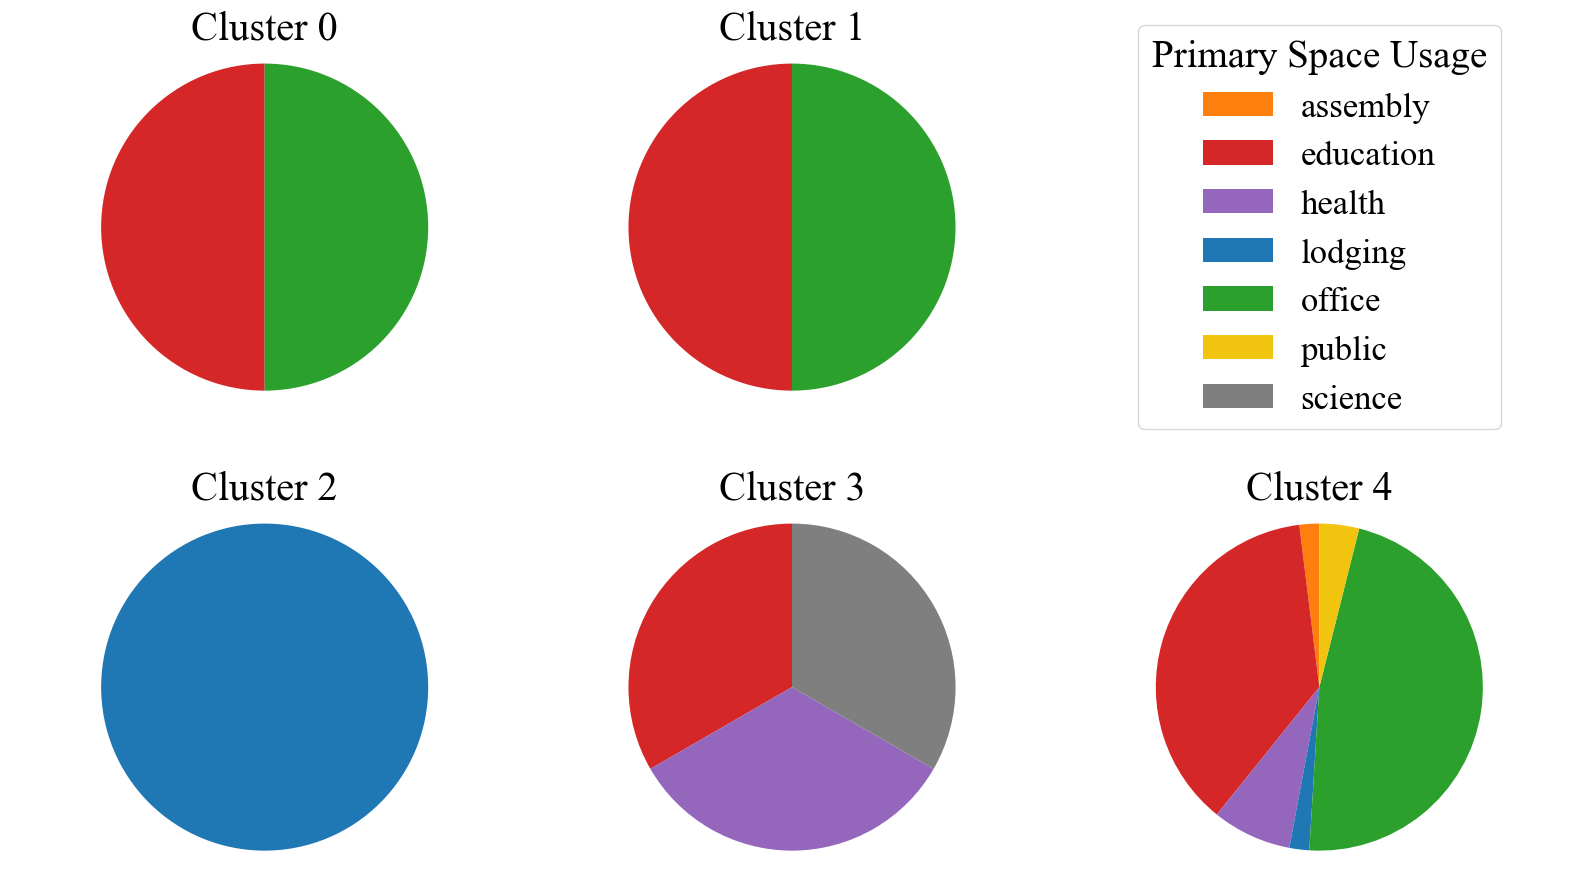

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from collections import Counter

# =========================
# 1. 读取数据
# =========================
csv_path = "kshape_results_1440_0Start/clusters_k5.csv"
df = pd.read_csv(csv_path)

# 拆分 location，取第二个单词
df["second_word"] = df["location"].str.split("_").str[1]

# =========================
# 2. 全局绘图风格
# =========================
word_colors = {
    "education": "#D62728",  # red
    "office": "#2CA02C",     # green
    "lodging": "#1F77B4",    # blue
    "health": "#9467BD",     # purple
    "science": "#7F7F7F",    # gray
    "public": "#F1C40F",     # yellow
    "assembly": "#FF7F0E",   # orange
}

# =========================
# 3. 统计 + 打印文字结果
# =========================
labels = sorted(df["label"].unique())
stats = {}

print("\n========== Label Statistics ==========\n")

for lb in labels:
    words = df.loc[df["label"] == lb, "second_word"]
    counter = Counter(words)
    stats[lb] = counter

    print(f"Cluster {lb}")
    print(f"  Total samples: {len(words)}")
    print("  Second word counts:")

    for k, v in counter.items():
        print(f"    {k}: {v}")

    print("-" * 40)

# 所有可能出现的 second_word（统一图例）
all_words = sorted(df["second_word"].unique())
# 为所有 second_word 生成对应颜色（顺序严格一致）
colors = [word_colors[w] for w in all_words]

# =========================
# 4. 创建画布与布局
# =========================
fig = plt.figure(figsize=(16, 9))

ax0 = plt.subplot2grid((2, 3), (0, 0))
ax1 = plt.subplot2grid((2, 3), (0, 1))
legend_ax = plt.subplot2grid((2, 3), (0, 2))

ax2 = plt.subplot2grid((2, 3), (1, 0))
ax3 = plt.subplot2grid((2, 3), (1, 1))
ax4 = plt.subplot2grid((2, 3), (1, 2))

axes = [ax0, ax1, ax2, ax3, ax4]

# =========================
# 5. 绘制饼图（不显示百分比）
# =========================
legend_handles = None

for lb, ax in zip(labels, axes):
    counter = stats[lb]
    sizes = [counter.get(w, 0) for w in all_words]

    wedges, texts = ax.pie(
        sizes,
        colors=colors,
        startangle=90
    )

    ax.set_title(f"Cluster {lb}", fontsize=title_fontsize)
    ax.axis("equal")

    if legend_handles is None:
        legend_handles = wedges

# =========================
# 6. 单独绘制图例
# =========================
legend_ax.axis("off")
legend_ax.legend(
    legend_handles,
    all_words,
    loc="center",
    fontsize=legend_fontsize,
    title="Primary Space Usage",
    title_fontsize=legend_title_fontsize
)

plt.tight_layout()
plt.show()



========== Label / Sub Primary Space Usage Statistics ==========

Cluster 0
  Total samples: 2
  Sub Primary Space Usage counts:
    E_College Laboratory: 1
    O_Office: 1
--------------------------------------------------
Cluster 1
  Total samples: 2
  Sub Primary Space Usage counts:
    E_College Laboratory: 1
    O_Office: 1
--------------------------------------------------
Cluster 2
  Total samples: 10
  Sub Primary Space Usage counts:
    L_Dormitory: 10
--------------------------------------------------
Cluster 3
  Total samples: 3
  Sub Primary Space Usage counts:
    E_College Classroom: 1
    H_Hospital: 1
    S_Laboratory: 1
--------------------------------------------------
Cluster 4
  Total samples: 51
  Sub Primary Space Usage counts:
    P_Library: 2
    E_College Laboratory: 17
    O_Office: 24
    E_College Classroom: 2
    A_Gymnasium: 1
    H_Hospital: 4
    L_Hotel: 1
--------------------------------------------------


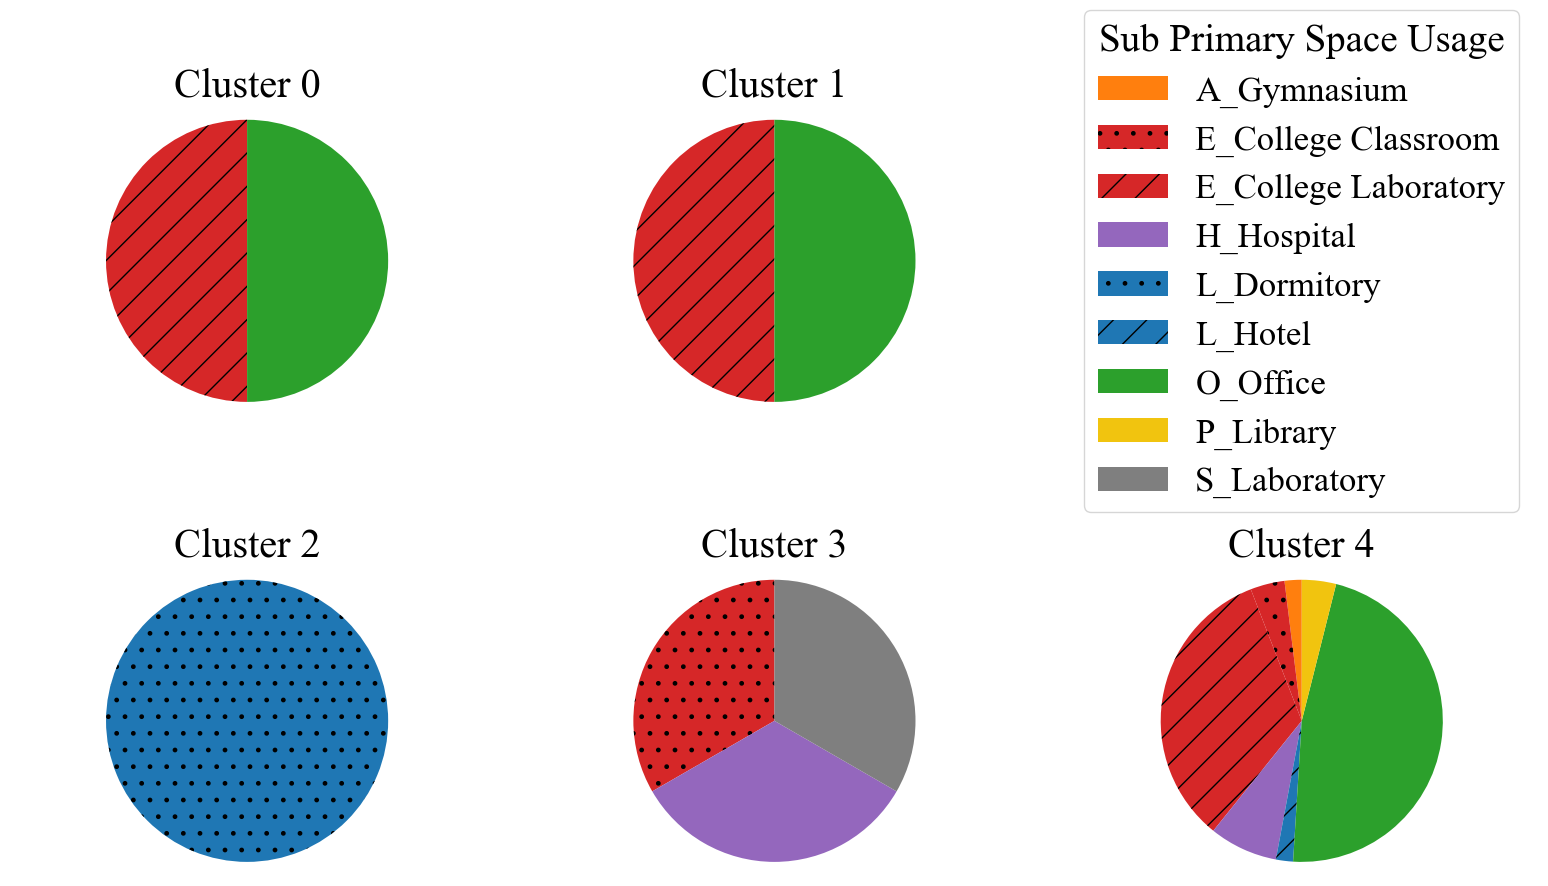

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from collections import Counter

# =========================
# 1. 读取 kshape 聚类结果
# =========================
cluster_path = "kshape_results_1440_0Start/clusters_k5.csv"
df_cluster = pd.read_csv(cluster_path)

# =========================
# 2. 读取 metadata
# =========================
meta_path = "../../data/metadata.csv"
df_meta = pd.read_csv(meta_path)

# 只保留需要的两列，避免冗余
df_meta = df_meta[["building_id", "sub_primarysSpaceUsage"]]

# =========================
# 3. 合并两个表
# location <-> building_id 一一对应
# =========================
df = df_cluster.merge(
    df_meta,
    left_on="location",
    right_on="building_id",
    how="left"
)

# 简单检查（可选）
if df["sub_primarysSpaceUsage"].isna().any():
    raise ValueError("存在 location 无法在 metadata 中找到对应的 Sub Primary Space Usage")

# =========================
# 4. 全局绘图风格
# =========================
word_colors = {
    "E_College Classroom": "#D62728",  # red
    "E_College Laboratory": "#D62728",  # red
    "O_Office": "#2CA02C",     # green
    "L_Dormitory": "#1F77B4",    # blue
    "L_Hotel": "#1F77B4",    # blue
    "H_Hospital": "#9467BD",     # purple
    "S_Laboratory": "#7F7F7F",    # gray
    "P_Library": "#F1C40F",     # yellow
    "A_Gymnasium": "#FF7F0E",   # orange
}

word_hatches = {
    "E_College Classroom": ".",     # black dots
    "E_College Laboratory": "/",    # black diagonal
    "L_Dormitory": ".",              # black dots
    "L_Hotel": "/",                  # black diagonal
}

# =========================
# 5. 统计 + 打印文字结果
# =========================
labels = sorted(df["label"].unique())
stats = {}

print("\n========== Label / Sub Primary Space Usage Statistics ==========\n")

for lb in labels:
    usages = df.loc[df["label"] == lb, "sub_primarysSpaceUsage"]
    counter = Counter(usages)
    stats[lb] = counter

    print(f"Cluster {lb}")
    print(f"  Total samples: {len(usages)}")
    print("  Sub Primary Space Usage counts:")

    for k, v in counter.items():
        print(f"    {k}: {v}")

    print("-" * 50)

# 所有可能的 usage（用于统一图例）
all_usages = sorted(df["sub_primarysSpaceUsage"].unique())
colors = [word_colors[w] for w in all_usages]
hatches = [word_hatches.get(w, None) for w in all_usages]

# =========================
# 6. 创建画布与布局
# =========================
fig = plt.figure(figsize=(16, 9))

ax0 = plt.subplot2grid((2, 3), (0, 0))
ax1 = plt.subplot2grid((2, 3), (0, 1))
legend_ax = plt.subplot2grid((2, 3), (0, 2))

ax2 = plt.subplot2grid((2, 3), (1, 0))
ax3 = plt.subplot2grid((2, 3), (1, 1))
ax4 = plt.subplot2grid((2, 3), (1, 2))

axes = [ax0, ax1, ax2, ax3, ax4]

# =========================
# 7. 绘制饼图（不显示百分比）
# =========================
legend_handles = None

for lb, ax in zip(labels, axes):
    counter = stats[lb]
    sizes = [counter.get(u, 0) for u in all_usages]

    wedges, texts = ax.pie(
        sizes,
        colors=colors,
        startangle=90
    )
    for w, h in zip(wedges, hatches):
        if h is not None:
            w.set_hatch(h)

    ax.set_title(f"Cluster {lb}", fontsize=title_fontsize)
    ax.axis("equal")

    if legend_handles is None:
        legend_handles = wedges

# =========================
# 8. 单独绘制图例
# =========================
legend_ax.axis("off")
legend_ax.legend(
    legend_handles,
    all_usages,
    loc="center",
    fontsize=legend_fontsize,
    title="Sub Primary Space Usage",
    title_fontsize=legend_title_fontsize
)

plt.tight_layout()
plt.show()
